# **Code-Switched Sentiment Analysis Pipeline**

###Framework: HuggingFace Transformers | Model: mBART-large-50
###Transfer Learning Approaches: PEFT (LoRA) vs Full Fine-Tuning

In [2]:
# Install necessary packages
!pip install emoji scikit-learn transformers sentencepiece torch

In [3]:
from huggingface_hub import login
import os
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [4]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import torch

In [5]:
file_path = "fixed_balanced_emotion_dataset.csv"
df = pd.read_csv(file_path, encoding='latin1')
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Dataset shape: (10330, 4)
Columns: ['ï»¿Unnamed: 0', 'Tweets', 'Level 1', 'Level 2']


,ï»¿Unnamed: 0,Tweets,Level 1,Level 2
0,7706,Han ji sir wait thoda sa bhari ho gya apka,no emotion,Neutral
1,11561,please make a vedio of gwader sea khe hander e...,no emotion,Neutral
2,4377,very nice apki videos bahot achi hoti han,emotion,Happy


In [6]:
df_clean = df.copy()

In [7]:
# Basic Cleaning
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s:]", " ", text)  # keep emoji codes
    text = re.sub(r"\s+"," ",text).strip()
    return text.lower()

In [8]:
# Urdu Normalization
norm_rules = {
    # 1. Phrases
    r"\b(bahut acha|bohot acha|bht acha)\b": "very good",
    r"\b(bohot ganda|bahut ganda|bht ganda)\b": "very bad",
    r"\b(bilkul nahi|bilkul nhi)\b": "not at all",
    r"\b(nahi kiya|nhi kiya)\b": "did not",
    r"\b(nahi hai|nhi hai|hai nahi)\b": "is not",
    r"\b(mat karo|mat kar)\b": "do not",
    r"\b(nahi tha|nhi tha)\b": "was not",
    r"\b(bura laga|bura lga)\b": "felt bad",

    # 2. Negations
    r"\b(nai|nhi|nahi|naa|ney|na|no)\b": "not",

    # 3. Intensifiers
    r"\b(bohot|bohat|bht|bhut|bahut)\b": "very",

    # 4. Positive Variations
    r"\b(achaa|achha|acha|achia)\b": "good",
    r"\b(khubsurat|khoobsurat|khubsorat)\b": "beautiful",
    r"\b(zabbardast|zabardast|zabrthast)\b": "amazing",
    r"\b(kamaal|kamal)\b": "amazing",
    r"\b(lajawaab|lajawab)\b": "excellent",
    r"\b(shandaar|shandar)\b": "wonderful",
    r"\b(pasand|psand)\b": "liked",
    r"\b(khushi|khush)\b": "happy",
    r"\b(mast|m मस्त)\b": "great",
    r"\b(wahh|waah|wah)\b": "wow",
    r"\b(badhiya|bdhiya)\b": "great",

    # 5. Negative Variations
    r"\b(bekar|bekaar|baykar)\b": "useless",
    r"\b(ghatya|ghatia)\b": "worst",
    r"\b(kharab|kharib|kharaab)\b": "bad",
    r"\b(bura|burra)\b": "bad",
    r"\b(ganda|gndaa)\b": "bad",
    r"\b(bewaqoof|bewakoof|bewaqof)\b": "stupid",
    r"\b(ghaleez|ghaleez)\b": "disgusting",
    r"\b(napassand|napasand)\b": "disliked",
    r"\bnagawar\b": "unpleasant",
    r"\btaklif\b": "pain",
    r"\b(dukh|dukk)\b": "sadness",
    r"\b(dard|drd)\b": "pain",
    r"\b(gussa|ghussa)\b": "angry",
    r"\b(pareshaan|preshan)\b": "troubled",
    r"\bafsos\b": "regret",
    r"\bnalayak\b": "incompetent",

    # 6. Social/Slang
    r"\b(ya|yar|yaar)\b": "yaar",
    r"\b(plz|pls|please)\b": "please",
    r"\b(thx|thanks|thnx)\b": "thanks",
    r"\bhahaha+\b": "haha",
    r"\b(haii|hay|haye)\b": "bhai",
}

def normalize_roman(text):
    for pattern,repl in norm_rules.items():
        text = re.sub(pattern,repl,text)
    return text

In [9]:
# Reduce repetitions
def remove_repeats(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

In [10]:
# Map emotion to sentiment
emotion_to_sentiment = {
    "Anger":0,
    "Sad":0,
    "Fear":0,
    "Disgust":0,
    "Happy":2,
    "Surprise":2,
    "Neutral":1
}

In [11]:
df_clean["clean_text"] = df_clean["Tweets"].apply(clean_text)

df_clean["clean_text"] = df_clean["clean_text"].apply(lambda x: emoji.demojize(x))

df_clean["normalized_text"] = df_clean["clean_text"].apply(normalize_roman)

df_clean["normalized_text"] = df_clean["normalized_text"].apply(remove_repeats)

df_clean["label_id"] = df_clean["Level 2"].map(emotion_to_sentiment)
df_clean = df_clean.dropna(subset=["label_id"])

In [12]:
# Back translation onf 5% of dataset using MarianMT
from transformers import MarianMTModel, MarianTokenizer

# English → Urdu
en2ur_model_name = "Helsinki-NLP/opus-mt-en-ur"
en2ur_tokenizer = MarianTokenizer.from_pretrained(en2ur_model_name)
en2ur_model = MarianMTModel.from_pretrained(en2ur_model_name)

# Urdu → English
ur2en_model_name = "Helsinki-NLP/opus-mt-ur-en"
ur2en_tokenizer = MarianTokenizer.from_pretrained(ur2en_model_name)
ur2en_model = MarianMTModel.from_pretrained(ur2en_model_name)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [13]:
def back_translate(texts, batch_size=16):
    augmented_texts = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # 1. Urdu -> English
        tokens = ur2en_tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to("cuda")
        translated_ids = ur2en_model.to("cuda").generate(**tokens)
        en_texts = [ur2en_tokenizer.decode(g, skip_special_tokens=True) for g in translated_ids]

        # 2. English -> Urdu
        tokens2 = en2ur_tokenizer(en_texts, return_tensors="pt", padding=True, truncation=True).to("cuda")
        translated_ids2 = en2ur_model.to("cuda").generate(**tokens2)
        ur_texts = [en2ur_tokenizer.decode(g, skip_special_tokens=True) for g in translated_ids2]

        augmented_texts.extend(ur_texts)
        print(f"Processed {len(augmented_texts)}/{len(texts)}...")

    return augmented_texts

In [14]:
from transformers import MBartForSequenceClassification, MBart50TokenizerFast

tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")
#tokenizer.src_lang = "en_XX"
tokenizer.src_lang = "hi_IN"

In [15]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from collections import Counter

# Step 1: Split FIRST (no augmentation yet)
df_clean_filtered = df_clean[["normalized_text", "label_id"]].copy()
df_clean_filtered = df_clean_filtered.dropna(subset=["normalized_text", "label_id"])
df_clean_filtered = df_clean_filtered[df_clean_filtered["normalized_text"].str.strip().astype(bool)]
df_clean_filtered = df_clean_filtered[df_clean_filtered["label_id"].isin([0, 1, 2])]
df_clean_filtered["label_id"] = df_clean_filtered["label_id"].astype(int)

train_raw, test = train_test_split(df_clean_filtered, test_size=0.15, random_state=42, stratify=df_clean_filtered["label_id"])
train_raw, val  = train_test_split(train_raw, test_size=0.15, random_state=42, stratify=train_raw["label_id"])

# Step 2: Augment ONLY the training set
df_aug = train_raw.sample(frac=0.05, random_state=42).copy()
df_aug["normalized_text"] = back_translate(df_aug["normalized_text"].tolist())
train_raw = pd.concat([train_raw, df_aug], ignore_index=True)
print("Train after augmentation:", len(train_raw))

# Step 3: Balance the training set
target = len(train_raw[train_raw["label_id"] == 1])
train_balanced = pd.concat([
    resample(train_raw[train_raw["label_id"] == 0], replace=True, n_samples=target, random_state=42),
    train_raw[train_raw["label_id"] == 1],
    resample(train_raw[train_raw["label_id"] == 2], replace=True, n_samples=target, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Train balanced:", Counter(train_balanced["label_id"]))
print("Val  (original):", Counter(val["label_id"]))
print("Test (original):", Counter(test["label_id"]))


Processed 16/373...
Processed 32/373...
Processed 48/373...
Processed 64/373...
Processed 80/373...
Processed 96/373...
Processed 112/373...
Processed 128/373...
Processed 144/373...
Processed 160/373...
Processed 176/373...
Processed 192/373...
Processed 208/373...
Processed 224/373...
Processed 240/373...
Processed 256/373...
Processed 272/373...
Processed 288/373...
Processed 304/373...
Processed 320/373...
Processed 336/373...
Processed 352/373...
Processed 368/373...
Processed 373/373...
Train after augmentation: 7836
Train balanced: Counter({0: 2273, 1: 2273, 2: 2273})
Val  (original): Counter({0: 510, 2: 424, 1: 383})
Test (original): Counter({0: 600, 2: 500, 1: 450})


In [16]:
train_balanced.to_csv("train_processed.csv", index=False)
val.to_csv("val_processed.csv", index=False)
test.to_csv("test_processed.csv", index=False)

print("Full preprocessing + tokenization complete")

Full preprocessing + tokenization complete


In [17]:
from datasets import Dataset

def prepare_dataset(df):
    hf_ds = Dataset.from_pandas(
        df[["normalized_text", "label_id"]].reset_index(drop=True)
    )

    def tokenize_fn(batch):
        return tokenizer(
            batch["normalized_text"],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors=None
        )

    hf_ds = hf_ds.map(tokenize_fn, batched=True)
    hf_ds = hf_ds.rename_column("label_id", "labels")
    hf_ds.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )
    return hf_ds

In [18]:
train_ds = prepare_dataset(train_balanced)
val_ds   = prepare_dataset(val)
test_ds  = prepare_dataset(test)

print("Sample input_ids shape:", train_ds[0]["input_ids"].shape)
print("Sample attention_mask shape:", train_ds[0]["attention_mask"].shape)
print("Sample label:", train_ds[0]["labels"])

Map:   0%|          | 0/6819 [00:00<?, ? examples/s]

Map:   0%|          | 0/1317 [00:00<?, ? examples/s]

Map:   0%|          | 0/1550 [00:00<?, ? examples/s]

Sample input_ids shape: torch.Size([128])
Sample attention_mask shape: torch.Size([128])
Sample label: tensor(0)


In [19]:
from collections import Counter
import torch

label_counts = Counter(train_balanced["label_id"])
print("Label distribution:", label_counts)

total = sum(label_counts.values())
class_weights = torch.tensor(
    [total / (3 * label_counts[i]) for i in range(3)],
    dtype=torch.float
).to("cuda")
print("Class weights:", class_weights)

Label distribution: Counter({0: 2273, 1: 2273, 2: 2273})
Class weights: tensor([1., 1., 1.], device='cuda:0')


In [20]:
from transformers import TrainingArguments, Trainer

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  if isinstance(logits, tuple):
    logits = logits[0]

  preds = np.argmax(logits, axis=-1)

  return {
      "accuracy": accuracy_score(labels, preds),
      "f1": f1_score(labels, preds, average="weighted")
  }


# **PEFT** **Fine Tuning**

In [21]:
import torch
torch.cuda.empty_cache()

In [22]:
from transformers import MBartForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

peft_model = MBartForSequenceClassification.from_pretrained(
    "facebook/mbart-large-50",
    num_labels=3,
    ignore_mismatched_sizes=True
)
peft_model.config.pad_token_id = tokenizer.pad_token_id
peft_model.get_input_embeddings().weight.requires_grad = True

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
MBartForSequenceClassification LOAD REPORT from: facebook/mbart-large-50
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classif

In [23]:
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

peft_model = get_peft_model(peft_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 17,334,368 || all params: 1,141,377,123 || trainable%: 1.5187


In [24]:
training_args = TrainingArguments(
    output_dir="./mbart-peft-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    logging_steps=50,
    lr_scheduler_type="linear",
    warmup_steps=500,
    gradient_accumulation_steps=4,
    max_grad_norm=1.0,
    label_smoothing_factor=0.1,
    report_to="none"
)

In [25]:
from accelerate.state import AcceleratorState, PartialState
from transformers import default_data_collator
AcceleratorState._reset_state(reset_partial_state=True)
PartialState()

trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=peft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [26]:
import time

start_time = time.time()
trainer.train()
end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,4.226799,1.040640,0.479119,0.479947
2,3.540547,0.868553,0.603645,0.607845
3,3.226313,0.776727,0.666667,0.659600
4,2.991588,0.782963,0.655277,0.656084
5,2.717311,0.790724,0.658314,0.660124
6,2.687911,0.769314,0.663629,0.666386


Total Training Time: 1389.59 seconds


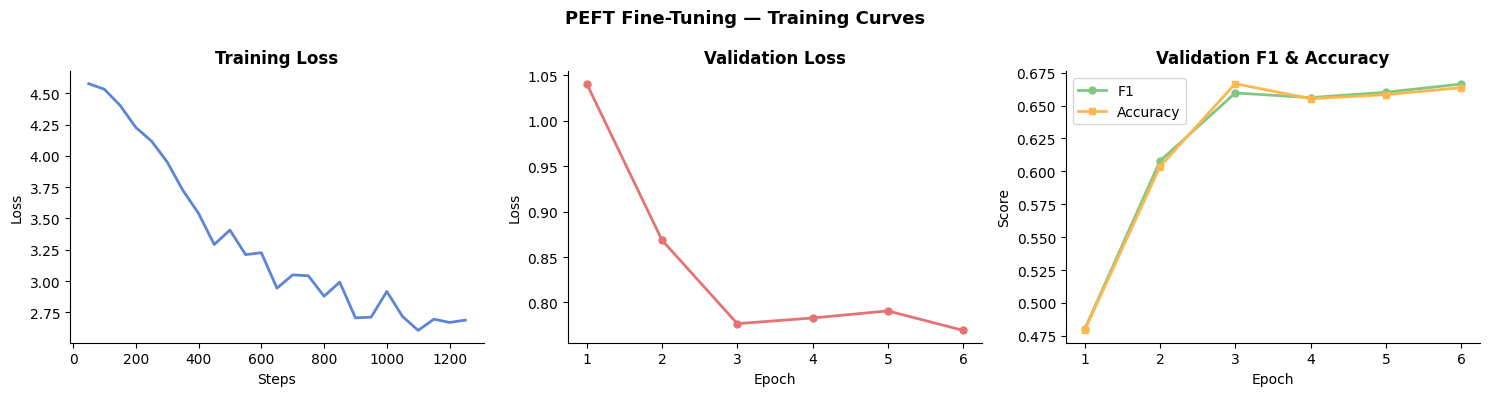

In [27]:
# PEFT Training Curves
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if train_logs:
    steps  = [x['step'] for x in train_logs]
    t_loss = [x['loss'] for x in train_logs]
    axes[0].plot(steps, t_loss, color='#5C85D6', linewidth=2)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Loss')
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

if eval_logs:
    epochs = [x['epoch']            for x in eval_logs]
    e_loss = [x['eval_loss']        for x in eval_logs]
    e_f1   = [x.get('eval_f1', 0)  for x in eval_logs]
    e_acc  = [x.get('eval_accuracy', 0) for x in eval_logs]

    axes[1].plot(epochs, e_loss, color='#E57373', linewidth=2, marker='o', markersize=5)
    axes[1].set_title('Validation Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

    axes[2].plot(epochs, e_f1,  color='#81C784', linewidth=2, marker='o', markersize=5, label='F1')
    axes[2].plot(epochs, e_acc, color='#FFB74D', linewidth=2, marker='s', markersize=5, label='Accuracy')
    axes[2].set_title('Validation F1 & Accuracy', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
    axes[2].legend()
    axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

fig.suptitle('PEFT Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [34]:
def peft_predict_sentiment(text, neutral_threshold=0.65):
  peft_model.eval()
  device = next(peft_model.parameters()).device

  text = clean_text(text)
  text = emoji.demojize(text)
  text = normalize_roman(text)
  text = remove_repeats(text)

  inputs = tokenizer(
      text, return_tensors="pt",
      padding=True, truncation=True, max_length=128
  ).to(device)

  with torch.no_grad():
      logits = peft_model(**inputs).logits

  probs = torch.softmax(logits, dim=-1)[0]


  if probs[1] >= neutral_threshold:
      pred = 1
  else:
      neg_pos_probs = probs.clone()
      neg_pos_probs[1] = 0
      pred = torch.argmax(neg_pos_probs).item()

  label_map = {
      0: "Negative (Anger/Sad/Fear/Disgust)",
      1: "Neutral",
      2: "Positive (Happy/Surprise)"
  }
  print(f"Prediction : {label_map[pred]}")
  print(f"Confidence → Neg: {probs[0]:.3f} | Neu: {probs[1]:.3f} | Pos: {probs[2]:.3f}")
  return label_map[pred]


In [35]:
reviews = [
    "Bro bahut acha tha. I really enjoyed it.",
    "Maza nahi aaya.",
    "Service theek thi, kuch special nahi tha.",
    "Food bahut tasty tha.",
    "Staff ka behavior acha nahi tha.",
    "Price thoda zyada laga.",
    "Jagah clean thi aur environment acha tha.",
    "Waiting time bahut zyada tha.",
    "Quality expected se better thi.",
    "Presentation achi thi lekin taste normal tha.",
    "Bilkul pasand nahi aaya.",
    "Value for money laga.",
    "Ambience kaafi boring tha.",
    "Experience kaafi acha raha."
]

print("PEFT Fine Tuning Sentiment Analysis")
for review in reviews:
    print("Review:", review)
    print("Predicted Sentiment:", peft_predict_sentiment(review))
    print("-" * 40)

PEFT Fine Tuning Sentiment Analysis
Review: Bro bahut acha tha. I really enjoyed it.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.013 | Neu: 0.017 | Pos: 0.970
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Maza nahi aaya.
Prediction : Neutral
Confidence → Neg: 0.246 | Neu: 0.651 | Pos: 0.104
Predicted Sentiment: Neutral
----------------------------------------
Review: Service theek thi, kuch special nahi tha.
Prediction : Neutral
Confidence → Neg: 0.107 | Neu: 0.773 | Pos: 0.120
Predicted Sentiment: Neutral
----------------------------------------
Review: Food bahut tasty tha.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.085 | Neu: 0.083 | Pos: 0.832
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Staff ka behavior acha nahi tha.
Prediction : Negative (Anger/Sad/Fear/Disgust)
Confidence → Neg: 0.301 | Neu: 0.453 | Pos: 0.245
Predicted Sentiment: Negative (Anger/

PEFT Fine-Tuning — Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.64      0.67       600
     Neutral       0.53      0.61      0.57       450
    Positive       0.78      0.76      0.77       500

    accuracy                           0.67      1550
   macro avg       0.67      0.67      0.67      1550
weighted avg       0.68      0.67      0.67      1550



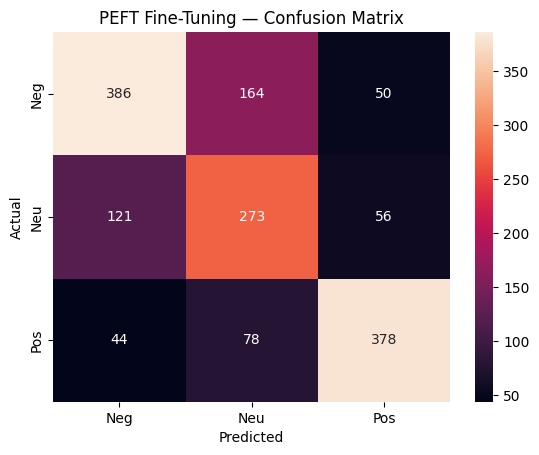

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

test_results = trainer.predict(test_ds)
predictions = test_results.predictions
if isinstance(predictions, tuple):
    predictions = predictions[0]

test_preds = np.argmax(predictions, axis=-1)
test_labels = test_results.label_ids

print("PEFT Fine-Tuning — Classification Report:")
print(classification_report(test_labels, test_preds, target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title("PEFT Fine-Tuning — Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [31]:
# Save PEFT results — run this before restarting runtime
import json
from sklearn.metrics import accuracy_score, f1_score

peft_results = {
    'test_f1'       : float(f1_score(test_labels, test_preds, average='weighted')),
    'test_accuracy'  : float(accuracy_score(test_labels, test_preds)),
    'train_time_sec' : float(end_time - start_time),
}

with open('peft_results.json', 'w') as f:
    json.dump(peft_results, f)

print('PEFT results saved:', peft_results)


PEFT results saved: {'test_f1': 0.6717357468858183, 'test_accuracy': 0.6690322580645162, 'train_time_sec': 1389.5937905311584}


# **Full Fine Tuning**

In [22]:
import torch
torch.cuda.empty_cache()

In [23]:
from transformers import MBartForSequenceClassification
import torch

full_model = MBartForSequenceClassification.from_pretrained(
    "facebook/mbart-large-50",
    num_labels=3,
    ignore_mismatched_sizes=True
)

full_model.gradient_checkpointing_enable()
full_model.config.use_cache = False
full_model = full_model.to("cuda")

total_params = sum(p.numel() for p in full_model.parameters())
trainable_params = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
print(f"Full Fine-Tuning — Total params    : {total_params:,}")
print(f"Full Fine-Tuning — Trainable params: {trainable_params:,}")


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
MBartForSequenceClassification LOAD REPORT from: facebook/mbart-large-50
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
lm_head.weight                      | UNEXPECTED | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 
classification_head.out_proj.weight | MISSING    | 
classif

Full Fine-Tuning — Total params    : 1,124,042,755
Full Fine-Tuning — Trainable params: 1,124,042,755


In [24]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./mbart_full_ft",
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    num_train_epochs=2,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True,
    optim="adafactor",
    logging_steps=200,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [25]:
from transformers import default_data_collator
from accelerate.state import AcceleratorState, PartialState

AcceleratorState._reset_state(reset_partial_state=True)
PartialState()

trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=full_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

In [26]:
import torch
import time

torch.cuda.empty_cache()

start_time = time.time()
trainer.train()
end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,13.967659,0.849819,0.648443,0.643973
2,10.275891,0.750023,0.685649,0.687345


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Total Training Time: 1936.29 seconds


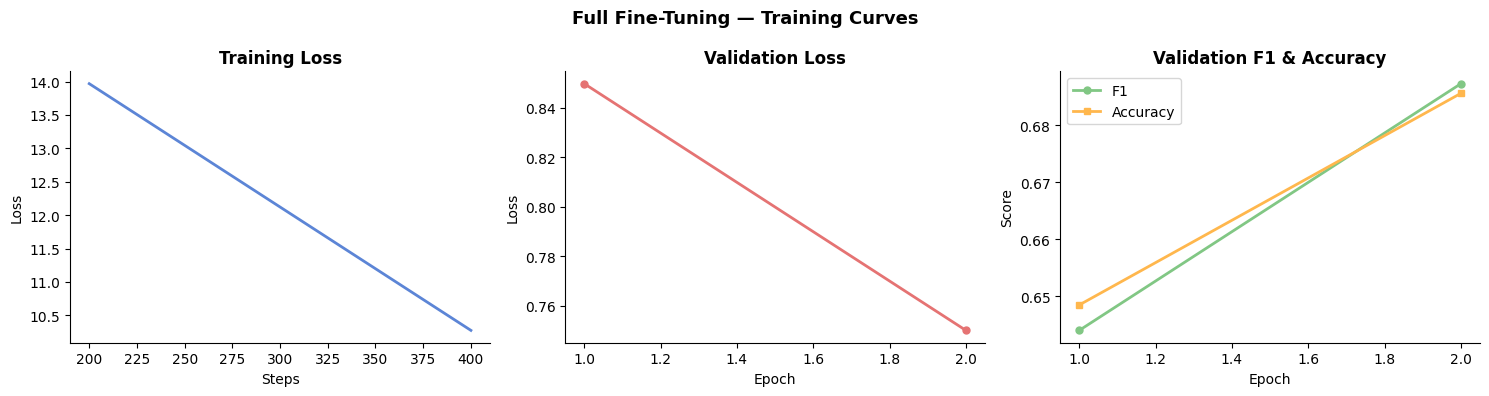

In [27]:
# Full Fine-Tuning Training Curves
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if train_logs:
    steps  = [x['step'] for x in train_logs]
    t_loss = [x['loss'] for x in train_logs]
    axes[0].plot(steps, t_loss, color='#5C85D6', linewidth=2)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Loss')
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

if eval_logs:
    epochs = [x['epoch']                for x in eval_logs]
    e_loss = [x['eval_loss']            for x in eval_logs]
    e_f1   = [x.get('eval_f1', 0)      for x in eval_logs]
    e_acc  = [x.get('eval_accuracy', 0) for x in eval_logs]

    axes[1].plot(epochs, e_loss, color='#E57373', linewidth=2, marker='o', markersize=5)
    axes[1].set_title('Validation Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

    axes[2].plot(epochs, e_f1,  color='#81C784', linewidth=2, marker='o', markersize=5, label='F1')
    axes[2].plot(epochs, e_acc, color='#FFB74D', linewidth=2, marker='s', markersize=5, label='Accuracy')
    axes[2].set_title('Validation F1 & Accuracy', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
    axes[2].legend()
    axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

fig.suptitle('Full Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [36]:
def full_predict_sentiment(text, neutral_threshold=0.78):
  full_model.eval()
  device = next(full_model.parameters()).device

  text = clean_text(text)
  text = emoji.demojize(text)
  text = normalize_roman(text)
  text = remove_repeats(text)

  inputs = tokenizer(
      text, return_tensors="pt",
      padding=True, truncation=True, max_length=128
  ).to(device)

  with torch.no_grad():
      logits = full_model(**inputs).logits

  probs = torch.softmax(logits, dim=-1)[0]


  if probs[1] >= neutral_threshold:
      pred = 1
  else:
      neg_pos_probs = probs.clone()
      neg_pos_probs[1] = 0
      pred = torch.argmax(neg_pos_probs).item()

  label_map = {
      0: "Negative (Anger/Sad/Fear/Disgust)",
      1: "Neutral",
      2: "Positive (Happy/Surprise)"
  }
  print(f"Prediction : {label_map[pred]}")
  print(f"Confidence → Neg: {probs[0]:.3f} | Neu: {probs[1]:.3f} | Pos: {probs[2]:.3f}")
  return label_map[pred]

In [37]:
reviews = [
    "Bro bahut acha tha. I really enjoyed it.",
    "Maza nahi aaya.",
    "Service theek thi, kuch special nahi tha.",
    "Food bahut tasty tha.",
    "Staff ka behavior bekar tha.",
    "Price thoda zyada laga.",
    "Jagah clean thi aur environment acha tha.",
    "Waiting time bahut zyada tha.",
    "Quality expected se better thi.",
    "Presentation achi thi lekin taste normal tha.",
    "Bilkul pasand nahi aaya.",
    "Value for money laga.",
    "Ambience kaafi boring tha.",
    "Experience kaafi acha raha."
]

print("Full Fine Tuning Sentiment Analysis")
for review in reviews:
    print("Review:", review)
    print("Predicted Sentiment:", full_predict_sentiment(review))
    print("-" * 40)

Full Fine Tuning Sentiment Analysis
Review: Bro bahut acha tha. I really enjoyed it.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.009 | Neu: 0.017 | Pos: 0.974
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Maza nahi aaya.
Prediction : Negative (Anger/Sad/Fear/Disgust)
Confidence → Neg: 0.178 | Neu: 0.760 | Pos: 0.062
Predicted Sentiment: Negative (Anger/Sad/Fear/Disgust)
----------------------------------------
Review: Service theek thi, kuch special nahi tha.
Prediction : Neutral
Confidence → Neg: 0.087 | Neu: 0.799 | Pos: 0.115
Predicted Sentiment: Neutral
----------------------------------------
Review: Food bahut tasty tha.
Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.099 | Neu: 0.084 | Pos: 0.817
Predicted Sentiment: Positive (Happy/Surprise)
----------------------------------------
Review: Staff ka behavior bekar tha.
Prediction : Negative (Anger/Sad/Fear/Disgust)
Confidence → Neg: 0.673 | Neu: 0.165 | 

Full Fine-Tuning — Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.64      0.67       600
     Neutral       0.55      0.62      0.59       450
    Positive       0.77      0.79      0.78       500

    accuracy                           0.68      1550
   macro avg       0.68      0.68      0.68      1550
weighted avg       0.69      0.68      0.68      1550



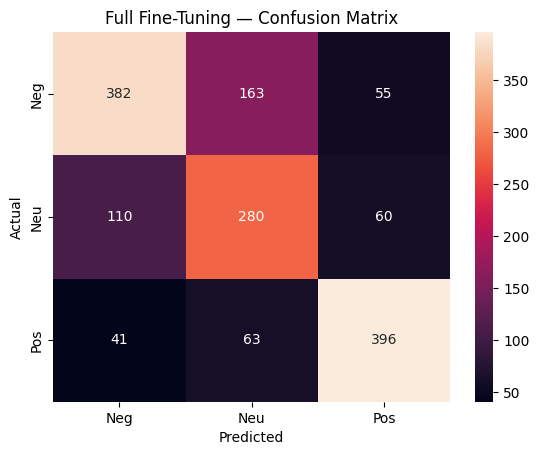

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

test_results = trainer.predict(test_ds)
predictions = test_results.predictions
if isinstance(predictions, tuple):
    predictions = predictions[0]

test_preds = np.argmax(predictions, axis=-1)
test_labels = test_results.label_ids

print("Full Fine-Tuning — Classification Report:")
print(classification_report(test_labels, test_preds, target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title("Full Fine-Tuning — Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


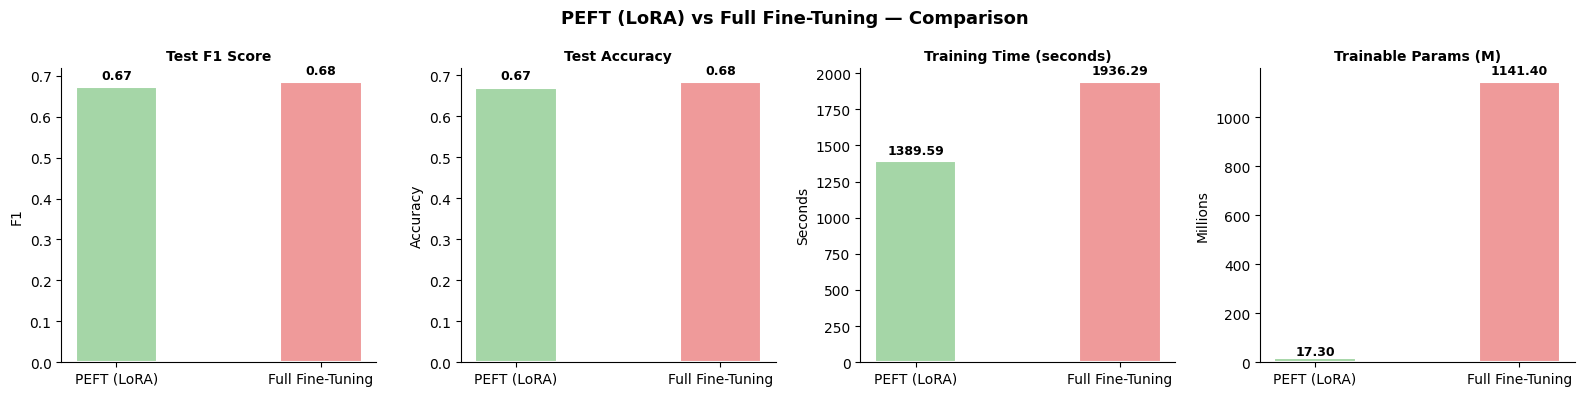

In [31]:
# PEFT vs Full Fine-Tuning — Final Comparison
import matplotlib.pyplot as plt
import json
from sklearn.metrics import accuracy_score, f1_score

with open('peft_results.json', 'r') as f:
    peft_results = json.load(f)

full_f1   = float(f1_score(test_labels, test_preds, average='weighted'))
full_acc  = float(accuracy_score(test_labels, test_preds))
full_time = float(end_time - start_time)

# peft_model.print_trainable_parameters()
peft_param_millions = 17.3   # 17,334,368 ÷ 1,000,000
full_param_millions = 1141.4  # 1,141,377,123 ÷ 1,000,000

methods = ['PEFT (LoRA)', 'Full Fine-Tuning']
metrics = [
    ([peft_results['test_f1'],        full_f1],   'Test F1 Score',          'F1'),
    ([peft_results['test_accuracy'],  full_acc],  'Test Accuracy',          'Accuracy'),
    ([peft_results['train_time_sec'], full_time], 'Training Time (seconds)','Seconds'),
    ([peft_param_millions, full_param_millions],  'Trainable Params (M)',   'Millions'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#A5D6A7', '#EF9A9A']

for ax, (vals, title, ylabel) in zip(axes, metrics):
    bars = ax.bar(methods, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:.2f}' if isinstance(val, float) else str(val),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('PEFT (LoRA) vs Full Fine-Tuning — Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
